# **Practica Cluster (Bootcamp)**

#### *k-means - cluster*

## *Importando Librerías*

In [2]:
#Importando librerías
import numpy as np #operaciones aritmeticas
import pandas as pd #limpieza y manipulacion de datos
import matplotlib.pyplot as plt # creacion de graficos y visualizaciones
import seaborn as sns # creacion de graficos mas atractivos y de facil interpretacion
from sklearn.preprocessing import StandardScaler #estandarizacion de los datos para tener una escala comparable
from sklearn.cluster import KMeans #agrupa los datos en diferentes cluster en base a sus caracteristicas
from sklearn.decomposition import PCA #reduccion de la cantidad de dimenciones de los datos mientras se conservan la mayor informacion posible
from sklearn.metrics import silhouette_score #medicion para saber que tan separados y definidos estan los grupos creados por KMeans

print("Librerias importadas correctamente ✔️")

Librerias importadas correctamente ✔️


### *Realizar la carga de los archivos y en caso de que no se encuentren los datos se crea el dataset*

In [3]:
try:
    import statsmodels.api as sm
    data = sm.datasets.get_rdataset('USArrests').data
except:
    data = pd.DataFrame({
        'Murder': [13.2, 10.0, 8.1, 8.8, 9.0, 7.9, 3.3, 5.9, 15.4, 17.4,
           5.3, 2.6, 10.4, 7.2, 2.2, 6.9, 9.7, 15.1, 8.2, 9.3,
           7.3, 4.4, 13.3, 5.5, 7.6, 9.6, 9.3, 5.0, 11.1, 7.6,
           14.9, 9.1, 11.3, 4.8, 9.9, 4.2, 5.9, 4.6, 11.7, 7.5,
           6.5, 10.5, 12.5, 7.7, 6.8, 4.3, 7.7, 4.2, 7.7, 7.2],
        
        'Assault': [236, 263, 294, 190, 276, 204, 110, 238, 335, 211,
            46, 120, 249, 113, 56, 115, 109, 249, 178, 243,
            93, 124, 337, 115, 216, 153, 185, 252, 205, 204,
            237, 239, 128, 102, 198, 120, 128, 116, 188, 169,
            106, 146, 184, 131, 141, 113, 145, 135, 136, 137],

        'UrbanPop': [58, 48, 80, 50, 91, 78, 72, 80, 80, 60,
             46, 48, 56, 58, 43, 75, 52, 66, 51, 65,
             48, 71, 88, 56, 59, 71, 73, 77, 49, 50,
             70, 55, 65, 84, 70, 55, 50, 53, 87, 65,
             41, 62, 64, 72, 46, 74, 67, 76, 65, 76],

        'Rape': [21.2, 14.3, 31.0, 19.5, 40.6, 38.7, 11.1, 15.8, 31.9, 25.8,
         20.2, 14.9, 18.1, 17.2, 11.5, 18.1, 16.3, 34.2, 25.8, 23.8,
         17.6, 22.0, 34.7, 15.1, 16.3, 14.8, 18.3, 19.4, 24.7, 26.2,
         26.2, 20.4, 21.2, 17.0, 17.6, 21.8, 18.7, 25.7, 22.0, 17.2,
         18.2, 15.6, 16.2, 20.8, 15.9, 17.1, 19.3, 22.3, 16.1, 18.1]
        
    }, index=['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
        'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia',
        'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas',
        'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts',
        'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana',
        'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey',
        'New Mexico', 'New York', 'North Carolina', 'North Dakota',
        'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island',
        'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia',
        'Wisconsin', 'Wyoming'])
    
print("Dataset creado exitosamente ✅")

Dataset creado exitosamente ✅


### *Se visualizan la vista previa de las 5 primeras filas del dataset*

In [4]:
data.head()

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


### *Aquí se visualizan las 5 últimas filas del DataFrame*

In [5]:
data.tail()

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Virginia,8.5,156,63,20.7
Washington,4.0,145,73,26.2
West Virginia,5.7,81,39,9.3
Wisconsin,2.6,53,66,10.8
Wyoming,6.8,161,60,15.6


### *Se realiza el resumen estadístico de las filas numéricas. Tomando en cuenta la media, desviación estándar, percentiles, etc.*

In [6]:
data.describe()

,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


#### *Se estandarizan las variables numéricas restando la media y dividiéndolas por la desviación estándar, dejando la media en 0 y la desviación estándar en 1. la  función principal es poner todas las características en la misma escala para evitar que las variables con valores grandes dominen a las de valores pequeños en los modelos de Machine Learning.*

In [7]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print(f"\n Datos Escalados {data} \nDatos Re-escalados {data_scaled}")


 Datos Escalados                 Murder  Assault  UrbanPop  Rape
rownames                                       
Alabama           13.2      236        58  21.2
Alaska            10.0      263        48  44.5
Arizona            8.1      294        80  31.0
Arkansas           8.8      190        50  19.5
California         9.0      276        91  40.6
Colorado           7.9      204        78  38.7
Connecticut        3.3      110        77  11.1
Delaware           5.9      238        72  15.8
Florida           15.4      335        80  31.9
Georgia           17.4      211        60  25.8
Hawaii             5.3       46        83  20.2
Idaho              2.6      120        54  14.2
Illinois          10.4      249        83  24.0
Indiana            7.2      113        65  21.0
Iowa               2.2       56        57  11.3
Kansas             6.0      115        66  18.0
Kentucky           9.7      109        52  16.3
Louisiana         15.4      249        66  22.2
Maine              2.1

### *Se implementa el elbow method y el Coeficiente de Silueta (Silhouette), donde Se mide la maxima distancia entre los puntos de un mismo cluster. Si es un 0 quiere decir que los cluster son superpuestos; si es un 1 quiere decir que los clusters estan bien separados  si es -1 los cluster estan asignados incorrectamente*

In [8]:
inertia = []
silhouette_scores = []
K_range = range(2,11)

In [9]:
for k in K_range:
# Con el metodo KMeans se analizan cuantos clusters se van a hacer(se inicializa el modelo de agrupamiento), y se indica que se dividan los datos k grupos de clusters
# Se fija una semilla aleatoria para que los datos puedan seleccionar de esta forma "aleatoriamente" y
# Se le indica al algoritmo que se ejecute 10 veces para quedarse con el mejor resultado 
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
# Se empieza a medir la capacidad del cluster
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(data_scaled, kmeans.labels_))

c:\Users\Hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

### *Pasamos a visualizar la informacion*

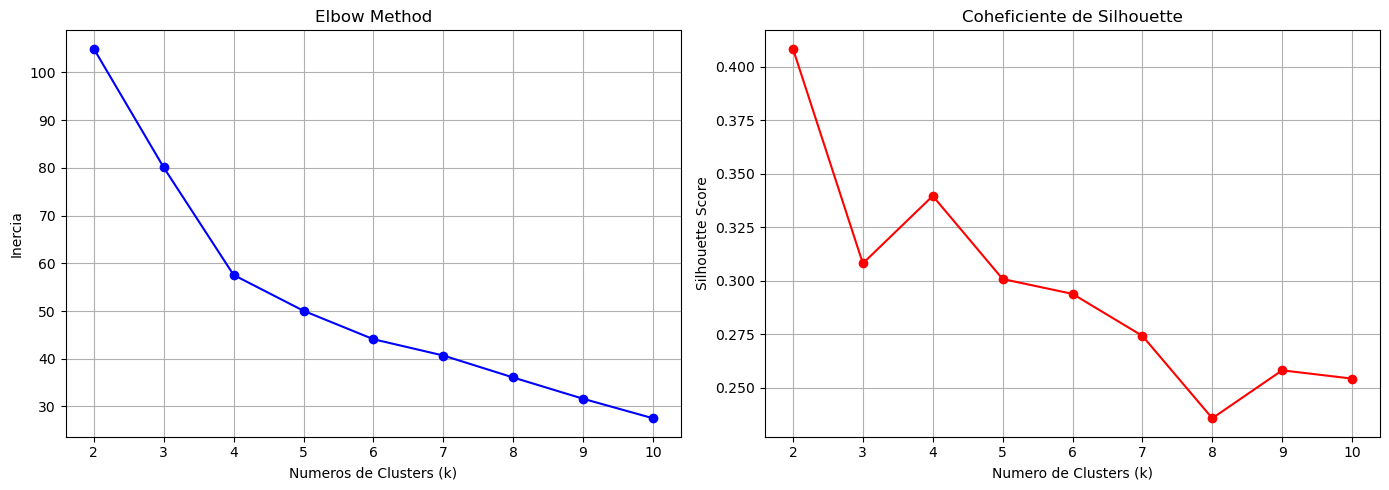

In [10]:
#se crea el subplot de una fila y dos columnas y el tamaño del grafico pasaria a ser de 14 pulgadas de ancho y 5 de alto
fix, axes = plt.subplots(1,2, figsize=(14,5))

# Representa la creación del Gráfico del Elbow Method
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_xlabel('Numeros de Clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

# Representa la creacion del Gráfico del Silhouette Score
axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Numero de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Coheficiente de Silhouette')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### *Aplicar la cantidad de Cluster*

In [11]:
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
data['cluster'] = kmeans.fit_predict(data_scaled)

c:\Users\Hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


###  ***Centroides*** 

In [12]:
centroides_scaled = kmeans.cluster_centers_
centroides_originales = scaler.inverse_transform(centroides_scaled)
centroides_df = pd.DataFrame(centroides_originales, 
                             columns= ['Murder', 'Assault', 'UrbanPop', 'Rape'])

print("\nCentroides de los Clusters (datos originales): ")
print("\n", centroides_df)


Centroides de los Clusters (datos originales): 

       Murder  Assault   UrbanPop      Rape
0   5.656250  138.875  73.875000  18.78125
1  12.165000  255.250  68.400000  29.16500
2   3.971429   86.500  51.928571  12.70000


### *Distribucion de los datos*

In [13]:
print(f"\nDistribucion de los Clusters: ")
print(data['cluster'].value_counts().sort_index())


Distribucion de los Clusters: 
cluster
0    16
1    20
2    14
Name: count, dtype: int64


### *Estado al que pertenece cada Cluster*

In [14]:
for cluster in range(k_optimo):
    estados = data[data['cluster'] == cluster].index.to_list()
    print(f"Cluster {cluster}: {estados}")

Cluster 0: ['Connecticut', 'Delaware', 'Hawaii', 'Indiana', 'Kansas', 'Massachusetts', 'New Jersey', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'Utah', 'Virginia', 'Washington', 'Wyoming']
Cluster 1: ['Alabama', 'Alaska', 'Arizona', 'California', 'Colorado', 'Florida', 'Georgia', 'Illinois', 'Louisiana', 'Maryland', 'Michigan', 'Mississippi', 'Missouri', 'Nevada', 'New Mexico', 'New York', 'North Carolina', 'South Carolina', 'Tennessee', 'Texas']
Cluster 2: ['Arkansas', 'Idaho', 'Iowa', 'Kentucky', 'Maine', 'Minnesota', 'Montana', 'Nebraska', 'New Hampshire', 'North Dakota', 'South Dakota', 'Vermont', 'West Virginia', 'Wisconsin']


### *Graficando los Clusters*

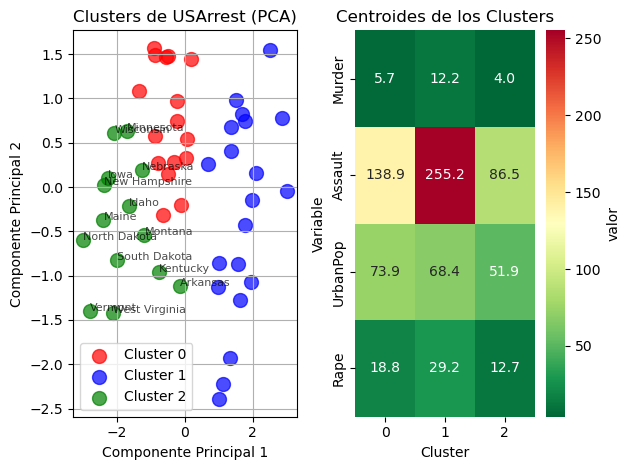

In [19]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)
plt.Figure(figsize=(12,8))

#Grafico 1: clusters en espacio PCA
plt.subplot(1,2,1)
color = ['red','blue','green','purple','orange','yellow']

for cluster in range(k_optimo):
    mask = data['cluster'] == cluster
    plt.scatter(data_pca[mask, 0], data_pca[mask, 1],
                c=color[cluster], label=f'Cluster {cluster}', alpha=0.7, s=100)

#añadir los nombres de los estados
for i, estado in enumerate(data.index[mask]):
    plt.annotate(estado, (data_pca[mask,0][i], data_pca[mask,1][i]),
                 fontsize=8, alpha=0.7)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters de USArrest (PCA)')
plt.legend()
plt.grid(True)

#Grafico 2: Mapa de calor de Centroides
plt.subplot(1,2,2)
sns.heatmap(centroides_df.T, annot=True, fmt='.1f', cmap='RdYlGn_r',
            cbar_kws={'label':'valor'})
plt.title('Centroides de los Clusters')
plt.xlabel('Cluster')
plt.ylabel('Variable')

plt.tight_layout()
plt.show()